In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

# tests/ -> project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [108]:
import torch

torch.manual_seed(42)
torch.random.manual_seed(42)


class BaseDynamics:
    def __init__(self, dt=1e-2):
        self.dt = dt

    def get_pos(self, x):
        return x

    def get_trajectories(self, x0, k, t, sigma_x=0.5):
        x = torch.empty((k, t, 2))

        x[:, 0] = x0

        for i in range(t - 1):
            x[:, i + 1] = self.get_pos(x[:, i]) + self.dt * sigma_x * torch.randn(k, 2)

        return x
    

class LimitCycle(BaseDynamics):
    def __init__(self, d, w, dt=1e-2):
        super().__init__(dt=dt)

        self.d = d
        self.w = w

    def get_pos(self, x):
        r = torch.sqrt(x[:, 0] ** 2 + x[:, 1] ** 2)
        theta = torch.arctan2(x[:, 1], x[:, 0])

        r += (r * (self.d - r ** 2)) * self.dt
        theta += self.w * self.dt

        return torch.stack([r * torch.cos(theta), r * torch.sin(theta)]).T



class Hopf(BaseDynamics):
    def __init__(self, mu, dt=1e-2):
        super().__init__(dt=dt)

        self.mu = mu
        self.dt = dt

    def get_pos(self, x):

        x[:, 0] += self.dt * x[:, 1]
        x[:, 1] += self.dt * (-x[:, 0] + (self.mu - x[:, 0] ** 2) * x[:, 1])

        return x


class FixedPoints(BaseDynamics):
    def __init__(self, mu, dt=1e-2):
        super().__init__(dt=dt)
        self.mu = mu

    def get_pos(self, x):

        x[:, 0] += self.dt * (self.mu * x[:, 0] - x[:, 0] ** 3)
        x[:, 1] += self.dt * (-x[:, 1])

        return x

In [171]:
#%% 
import os
import numpy as np
import numpy.random as npr
import torch
import itertools

torch.manual_seed(42)
torch.random.manual_seed(42)
npr.seed(0)

def generate_observations(x, dy, sigma_y, same_likelihood=False):
    K, T, dx = x[0].shape
    if same_likelihood:
        assert isinstance(dy, int)
        C = torch.randn(dx, dy) / np.sqrt(dx)
        y = [x[i]@C + sigma_y * torch.randn(K, T, dy) for i in range(len(x))]
    else:
        C = [torch.randn(dx, dy[i]) / np.sqrt(dx) for i in range(len(dy))]
        y = [x[i] @ C[i] + sigma_y * torch.randn(K, T, dy[i]) for i in range(len(dy))]
    return C, y


def generate_latents(dynamics_type, K, T, dx, mu_list):
    x = []
    for mu in mu_list:
        if dynamics_type == 'hopf':
            dynamics = Hopf(mu)
        elif dynamics_type == 'fixed_points':
            dynamics = FixedPoints(mu)
        elif dynamics_type == 'limit_cycle':
            dynamics = LimitCycle(2, mu)
        elif dynamics_type == 'lotka_volterra':
            dynamics = LotkaVolterra(alpha = 5, beta = mu[0], gamma = 5, delta = mu[1])

        if dynamics_type == 'lotka_volterra':
            # Remove noise and adjust initial condition to avoid negative values
            x0 = torch.rand(K, dx) * 2 + 1
            x.append(dynamics.get_trajectories(x0, K, T).float()[:, ::3])
        else:
            x0 = torch.randn(K, dx)
            x.append(dynamics.get_trajectories(x0, K, T).float()[:, ::3])
    return x


dynamics_type = 'limit_cycle'

dx = 2
sigma_x = 0.5  # state noise
sigma_y = 0.1  # observation noise

K = 1_000  # number of batches
T = 1_000  # length of time series


mu_list = [-5, -2.5, 2.5, 5]

dy = np.random.choice(np.arange(20, 60).astype(int), len(mu_list))

x = generate_latents(dynamics_type, K, T, dx, mu_list)
C, y = generate_observations(x, dy, sigma_y, same_likelihood=False)

In [172]:
y[0].shape

torch.Size([1000, 334, 20])

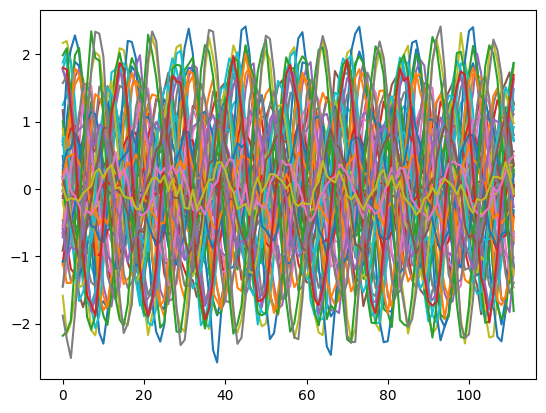

In [177]:
import matplotlib.pyplot as plt

plt.plot(y[3][0, ::3])
plt.show()

In [ ]:

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- 3 datasets/modalities ----
Dobs = [y[i].shape[-1] for i in range(4)]
batch = {'0': {'y': y[0][:32, ::3]},
         '1': {'y': y[1][:32, ::3]},
         '2': {'y': y[2][:32, ::3]},
         '3': {'y': y[3][:32, ::3]}}


In [182]:
from omegaconf import OmegaConf
from hydra.utils import instantiate

cfg = OmegaConf.load("../configs/model/meta_ssm.yaml")

d_obs = {'0': Dobs[0], '1': Dobs[1], '2': Dobs[2], '3': Dobs[3]}

adapters = instantiate(cfg.model.adapters, dim_observations=d_obs)
model = instantiate(cfg.model, adapters=adapters).to(device)


In [183]:
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)

for i in range(200):
    opt.zero_grad()

    out = model(batch, p_mask=0.2)
    loss = out['loss']

    loss.backward()

    opt.step()

    if i % 10 == 0:
        print(f'loss = {loss.item()}')

loss = 21818.8125
loss = 21369.35546875
loss = 21066.84375
loss = 20819.01953125
loss = 20699.10546875
loss = 20551.46484375
loss = 20434.0703125
loss = 20332.466796875
loss = 20223.140625
loss = 20080.1953125
loss = 19944.296875
loss = 19813.96484375
loss = 19678.69140625
loss = 19538.07421875
loss = 19400.96484375
loss = 19247.921875
loss = 19081.44140625
loss = 18951.984375
loss = 18811.7578125
loss = 18657.78125


In [184]:
batch_test = {'0': {'y': y[0][32:64, ::2]},
              '1': {'y': y[1][32:64, ::2]},
              '2': {'y': y[2][32:64, ::2]},
              '3': {'y': y[3][32:64, ::2]}}

In [185]:
with torch.no_grad():
    out = model(batch_test, return_outputs=True)

In [186]:
e_samples = []

for k in batch.keys():
    e_samples.append(out['outputs_by_dataset'][k]['e'])

In [187]:
e_samples

[tensor([[1.7914]]),
 tensor([[-0.5962]]),
 tensor([[-1.1756]]),
 tensor([[0.4074]])]

In [188]:
from meta_ssm.utils.variational import reparametrize

In [189]:
e_samples = []

for ds, b in batch.items():
    y_ds = b["y"]

    with torch.no_grad():
        y_bar = model.adapters.readin[ds](y_ds)  # [b,T,dim_shared]

        # 2) task/dataset embedding
        mu_e, var_e = model.embedding_encoder(y_bar)
        e = reparametrize(mu_e, var_e, n_samples=5)

        e_samples.append(e)

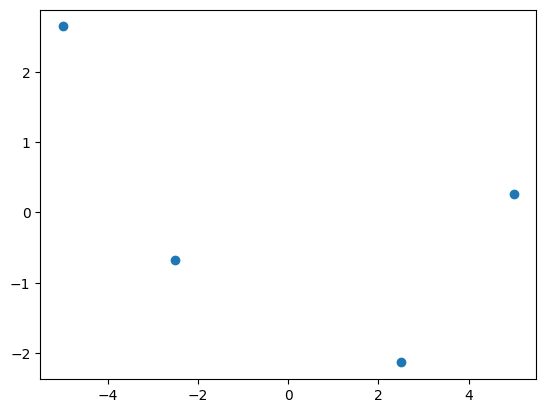

In [200]:
plt.plot(mu_list, torch.stack(e_samples).squeeze()[:, 1], 'o')
plt.show()